# Quantum Computing Training

## Lecture 3

### Last Lecture
1. Binary numbers, bitwise addition, and multiplication
2. Hadamard Identities
3. Simon's algorithm for finding hidden XOR structure

Simon's algorithm showed the pattern:

$$\text{hidden XOR structure} \rightarrow \text{superposition} \rightarrow \text{oracle} \rightarrow \text{interference via Hadamards} \rightarrow \text{classical post-processing}.$$

Shor's algorithm follows the same spirit:

$$\text{hidden period/phase structure} \rightarrow \text{superposition} \rightarrow \text{oracle} \rightarrow \text{interference via QFT} \rightarrow \text{classical post-processing}.$$

### Today: QFT and QPE
1. The Quantum Fourier Transform
2. Quantum Phase Estimation

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

np.set_printoptions(precision=3, suppress=True)


def bits(j, n):
    return format(j, f'0{n}b')


def qft_state_phases(j, n):
    N = 2**n
    return np.exp(2j*np.pi*j*np.arange(N)/N)/np.sqrt(N)


# Fourier Transform Background

Before the **quantum** Fourier transform, let's review the classical idea.

A Fourier transform is a change of coordinates from time (or position) space to frequency (or momentum) space.

Instead of describing data by **where it is in time or position**, we describe it by **which repeating patterns it contains**.

## Time view versus frequency view

Suppose we have a variable $x$ that is sampled at $N$ timesteps:

$$x_0,x_1,x_2,\ldots,x_{N-1}.$$

The **time view** stores the value at each sample index $t$.

The **frequency view** identifies and records whether there is a repeating pattern present in $x_0,x_1,x_2,\ldots,x_{N-1}$.

## The discrete Fourier transform

For finite arrays, we use the **discrete Fourier transform**.

Define the basic complex phase step

$$\alpha_N=e^{2\pi i/N}.$$

The DFT coefficient at frequency index $k$ is

$$X_k=\sum_{t=0}^{N-1} x_t\alpha_N^{-kt}.$$

Interpretation:

$$X_k=\text{how much the data looks like a wave with }k\text{ cycles}.$$

The minus sign is a common classical convention. The QFT later uses the same idea with the opposite sign convention.

Either way, the key operation is comparing data to many rotating phase patterns.

## Visual example: two hidden frequencies

Below, we create a fake signal with two ingredients:

$$x_t=\sin\left(2\pi\cdot 3t/N\right)+0.5\sin\left(2\pi\cdot 9t/N\right),\qquad N=64.$$

A few sample values look like this:

| $t$ | $x_t$ |
|---:|---:|
| 0 | 0.000 |
| 1 | 0.677 |
| 2 | 1.046 |
| 3 | 1.009 |
| 4 | 0.733 |
| 5 | 0.517 |
| 6 | 0.565 |
| 7 | 0.833 |
| 8 | 1.061 |
| 9 | 0.969 |
| 10 | 0.473 |
| 11 | -0.243 |
| 12 | -0.845 |
| 13 | -1.075 |
| 14 | -0.929 |
| 15 | -0.640 |

The DFT output is mostly zero except at the hidden frequencies:

| frequency index $k$ | DFT coefficient $X_k$ | magnitude |
|---:|---:|---:|
| 0 | $0$ | 0 |
| 1 | $0$ | 0 |
| 2 | $0$ | 0 |
| 3 | $-32i$ | 32 |
| 4 | $0$ | 0 |
| ... | ... | ... |
| 9 | $-16i$ | 16 |

So the sample plot mixes the two frequencies together, while the Fourier plot makes them visible as peaks at $k=3$ and $k=9$.

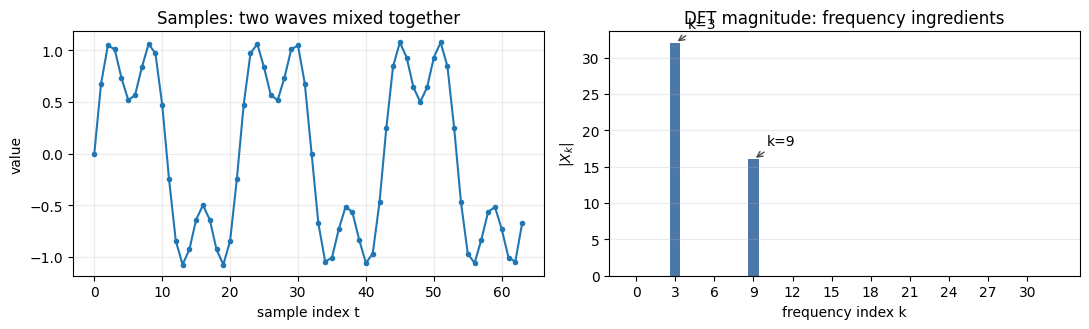

In [2]:
N = 64
sample_index = np.arange(N)
signal = np.sin(2*np.pi*3*sample_index/N) + 0.5*np.sin(2*np.pi*9*sample_index/N)
spectrum = np.fft.rfft(signal)
frequencies = np.arange(len(spectrum))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(sample_index, signal, marker='o', markersize=3, linewidth=1.5)
axes[0].set_title('Samples: two waves mixed together')
axes[0].set_xlabel('sample index t')
axes[0].set_ylabel('value')
axes[0].grid(alpha=0.25)

axes[1].bar(frequencies, np.abs(spectrum), color='#4c78a8')
axes[1].set_title('DFT magnitude: frequency ingredients')
axes[1].set_xlabel('frequency index k')
axes[1].set_ylabel(r'$|X_k|$')
axes[1].set_xticks(range(0, len(spectrum), 3))
axes[1].grid(axis='y', alpha=0.25)
for peak in [3, 9]:
    axes[1].annotate(f'k={peak}', xy=(peak, np.abs(spectrum[peak])), xytext=(peak + 1, np.abs(spectrum[peak]) + 2),
                     arrowprops={'arrowstyle': '->', 'color': '0.3'}, fontsize=10)
plt.tight_layout()

# Quantum Fourier Transform

## DFT

$$\alpha_N=e^{2\pi i/N}, \qquad X_k=\sum_{t=0}^{N-1} x_t\alpha_N^{-kt}.$$

## QFT

Let $N=2^n$ and define

$$\alpha_N=e^{2\pi i/N}.$$

The QFT is the unitary map

$$\boxed{|j\rangle \mapsto \frac{1}{\sqrt N}\sum_{k=0}^{N-1}\alpha_N^{jk}|k\rangle.}$$

Writing out the phase,

$$\alpha_N^{jk}=e^{2\pi i jk/N}.$$

So the amplitude of output basis state $|k\rangle$ is

$$\frac{1}{\sqrt N}e^{2\pi i jk/N}.$$

Every output has the same magnitude $1/\sqrt N$; only the phase depends on $j$ and $k$.

By linearity, if

$$|\psi\rangle=\sum_{j=0}^{N-1} a_j|j\rangle,$$

then

$$\operatorname{QFT}|\psi\rangle
=\sum_{k=0}^{N-1}\left(\frac{1}{\sqrt N}\sum_{j=0}^{N-1}a_j e^{2\pi i jk/N}\right)|k\rangle.$$

Those new amplitudes are the discrete Fourier transform of the old amplitudes.

## An Example

For $N=8$, define $\alpha=e^{2\pi i/8}$.

Then

$$|j\rangle \mapsto \frac{1}{\sqrt8}\left(|0\rangle + \alpha^j|1\rangle + \alpha^{2j}|2\rangle+\cdots+\alpha^{7j}|7\rangle\right).$$

The exponent on the $|k\rangle$ term is $jk$:

$$\text{amplitude of }|k\rangle=\frac{1}{\sqrt8}\alpha^{jk}.$$

Examples:

$$|0\rangle \mapsto \frac{1}{\sqrt8}(1,1,1,1,1,1,1,1),$$

$$|1\rangle \mapsto \frac{1}{\sqrt8}(1,\alpha,\alpha^2,\alpha^3,\ldots,\alpha^7),$$

$$|2\rangle \mapsto \frac{1}{\sqrt8}(1,\alpha^2,\alpha^4,\alpha^6,\ldots,\alpha^{14}).$$

The value $j$ becomes a frequency: larger $j$ means the phases wind faster as $k$ increases.

# QFT Circuit

## Binary fractions

The QFT circuit becomes transparent if we write phases as binary fractions.

For bits $j_{n-1}\cdots j_1j_0$,

$$j = 2^{n-1}j_{n-1}+\cdots+2j_1+j_0.$$

A binary fraction means

$$0.j_mj_{m-1}\cdots j_0 = \frac{j_m}{2}+\frac{j_{m-1}}{4}+\cdots+\frac{j_0}{2^{m+1}}.$$

Example:

$$0.101_2 = \frac12 + 0 + \frac18 = \frac58.$$

The useful identity is

$$e^{2\pi i(\text{integer}+\theta)}=e^{2\pi i\theta}.$$

So when a phase contains an integer part, we can drop it and keep only the fractional bits.

## One-qubit QFT

Start from the QFT definition:

$$|j\rangle\mapsto \frac{1}{2^{n/2}}\sum_{k=0}^{2^n-1} e^{2\pi i jk/2^n}|k\rangle.$$

For one qubit,

$$|j\rangle \mapsto \frac{1}{\sqrt2}\sum_{k=0}^{1}e^{2\pi i jk/2}|k\rangle.$$

Write the two terms explicitly:

$$|j\rangle \mapsto \frac{1}{\sqrt2}\left(e^{2\pi i j\cdot 0/2}|0\rangle+e^{2\pi i j\cdot 1/2}|1\rangle\right).$$

Since $e^0=1$ and $e^{2\pi i j/2}=e^{\pi i j}=(-1)^j$,

$$|j\rangle \mapsto \frac{|0\rangle+(-1)^j|1\rangle}{\sqrt2}.$$

Therefore

$$|0\rangle\mapsto |+\rangle, \qquad |1\rangle\mapsto |-\rangle.$$

The one-qubit QFT is exactly $H$.

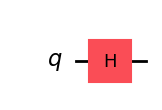

In [3]:
qc = QuantumCircuit(1)
qc.h(0)
qc.draw(output='mpl')

## Two-qubit QFT

Let $n=2$, so $N=2^n=4$.

The QFT is

$$|j\rangle\mapsto \frac{1}{2}\sum_{k=0}^{3}e^{2\pi i jk/4}|k\rangle.$$

Now replace $k$ with its bits:

$$|j\rangle\mapsto \frac{1}{2}\sum_{k_1=0}^{1}\sum_{k_0=0}^{1}
e^{2\pi i j(2k_1+k_0)/4}|k_1k_0\rangle.$$

Split the exponent:

$$\frac{j(2k_1+k_0)}{4}=\frac{jk_1}{2}+\frac{jk_0}{4}.$$

So

$$e^{2\pi i j(2k_1+k_0)/4}
=e^{2\pi i jk_1/2}e^{2\pi i jk_0/4}.$$

Continue from

$$|j\rangle\mapsto \frac{1}{2}\sum_{k_1=0}^{1}\sum_{k_0=0}^{1}
e^{2\pi i j(2k_1+k_0)/4}|k_1k_0\rangle = \frac{1}{2}\sum_{k_1=0}^{1}\sum_{k_0=0}^{1}
e^{2\pi i jk_1/2}e^{2\pi i jk_0/4}|k_1\rangle|k_0\rangle.$$

The $k_1$ choice only appears in the first exponential, and the $k_0$ choice only appears in the second exponential.

Therefore the double sum factors:

$$\frac{1}{2}
\left(\sum_{k_1=0}^{1}e^{2\pi i jk_1/2}|k_1\rangle\right)
\left(\sum_{k_0=0}^{1}e^{2\pi i jk_0/4}|k_0\rangle\right).$$

Now write out each two-term sum:

$$=\frac{1}{2}
\left(|0\rangle+e^{2\pi i j/2}|1\rangle\right)
\left(|0\rangle+e^{2\pi i j/4}|1\rangle\right).$$

So,

$$|j\rangle\mapsto \frac{1}{2}
\left(|0\rangle+e^{2\pi i j/2}|1\rangle\right)
\left(|0\rangle+e^{2\pi i j/4}|1\rangle\right).$$

Now simplify the phases using the bits of $j$.

For two qubits,

$$j=2j_1+j_0.$$

First phase:

$$\frac{j}{2}=j_1+\frac{j_0}{2}.$$

The integer part $j_1$ does not affect $e^{2\pi i(\cdot)}$, so

$$e^{2\pi ij/2}=e^{2\pi i(0.j_0)}.$$

Second phase:

$$\frac{j}{4}=\frac{j_1}{2}+\frac{j_0}{4}=0.j_1j_0.$$

So the two-qubit QFT output is

$$|j_1j_0\rangle\mapsto
\frac{|0\rangle+e^{2\pi i0.j_0}|1\rangle}{\sqrt2}
\frac{|0\rangle+e^{2\pi i0.j_1j_0}|1\rangle}{\sqrt2},$$

up to the final reversal of qubit order.

## Product Form: General Pattern

For $n$ qubits, write

$$k=2^{n-1}k_{n-1}+\cdots+2k_1+k_0.$$

Then

$$e^{2\pi i jk/2^n}
=e^{2\pi i j(2^{n-1}k_{n-1})/2^n}\cdots e^{2\pi i j(2k_1)/2^n}e^{2\pi i jk_0/2^n}.$$

Because each output bit $k_m$ appears in its own factor, the full sum factors into one qubit at a time.

After dropping integer parts in the phases, the QFT becomes

$$|j_{n-1}\cdots j_0\rangle \mapsto \frac{1}{2^{n/2}}
\left(|0\rangle+e^{2\pi i 0.j_0}|1\rangle\right)
\left(|0\rangle+e^{2\pi i 0.j_1j_0}|1\rangle\right)
\cdots
\left(|0\rangle+e^{2\pi i 0.j_{n-1}\cdots j_0}|1\rangle\right),$$

again up to the final qubit reversal.

## Building the 2-qubit QFT Circuit

Let the input be $|j_1j_0\rangle$.

The product form says the output qubits should be

$$\frac{|0\rangle+e^{2\pi i 0.j_0}|1\rangle}{\sqrt2}
\otimes
\frac{|0\rangle+e^{2\pi i 0.j_1j_0}|1\rangle}{\sqrt2},$$

up to the final qubit reversal.

A Hadamard on a bit $b$ creates

$$|b\rangle\xrightarrow{H}\frac{|0\rangle+(-1)^b|1\rangle}{\sqrt2}
=\frac{|0\rangle+e^{2\pi i b/2}|1\rangle}{\sqrt2}.$$

That gives the $j_1/2$ or $j_0/2$ phase contribution.

A **controlled phase rotation** adds a smaller phase only when both conditions are true:

1. the control qubit is $|1\rangle$,
2. the target branch is the $|1\rangle$ part of its superposition.

For angle $\theta$, the controlled phase gate acts as

$$|00\rangle\mapsto |00\rangle,\quad |01\rangle\mapsto |01\rangle,\quad |10\rangle\mapsto |10\rangle,\quad |11\rangle\mapsto e^{i\theta}|11\rangle.$$

So a controlled phase with

$$\theta=2\pi\cdot \frac{1}{4}=\frac{\pi}{2}$$

adds exactly the $j_0/4$ piece needed in

$$e^{2\pi i0.j_1j_0}=e^{2\pi i(j_1/2+j_0/4)}.$$

Circuit recipe: Hadamards create the half-turn phases; controlled phase gates add the quarter-turn, eighth-turn, and smaller phase corrections.

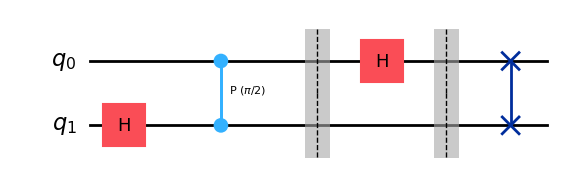

In [4]:
def qft_circuit(n, do_swaps=True):
    qc = QuantumCircuit(n, name='QFT')
    for target in reversed(range(n)):
        qc.h(target)
        for control in reversed(range(target)):
            angle = np.pi / (2 ** (target - control))
            qc.cp(angle, control, target)
        qc.barrier()
    if do_swaps:
        for q in range(n // 2):
            qc.swap(q, n - q - 1)
    return qc

qft2 = qft_circuit(2)
qft2.draw(output='mpl')

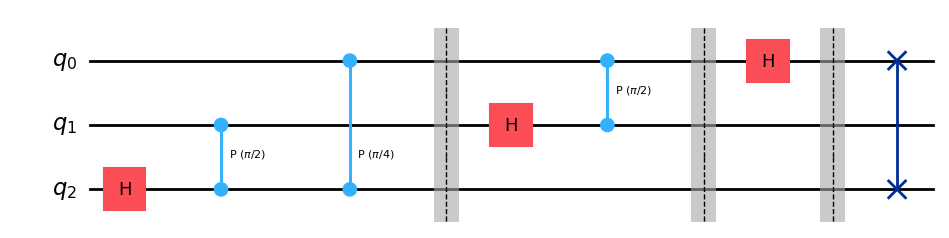

In [5]:
qft3 = qft_circuit(3)
qft3.draw(output='mpl')

## Checking the QFT against the formula

For a chosen input $|j\rangle$, the formula predicts

$$\frac{1}{\sqrt{2^n}}\sum_{k=0}^{2^n-1}e^{2\pi i jk/2^n}|k\rangle.$$

To check a circuit, compare each output amplitude:

$$c_k^{\text{circuit}}\quad\text{versus}\quad c_k^{\text{formula}}=\frac{1}{\sqrt{2^n}}e^{2\pi i jk/2^n}.$$

Small warning: software libraries choose a qubit ordering convention. The swaps at the end are there to align the circuit with the integer label convention.

In [6]:
def basis_prep(n, j):
    qc = QuantumCircuit(n)
    for q, bit in enumerate(reversed(bits(j, n))):
        if bit == '1':
            qc.x(q)
    return qc

n = 3
j = 5
qc = basis_prep(n, j).compose(qft_circuit(n))
state = Statevector.from_instruction(qc).data
formula = qft_state_phases(j, n)
print('Max |circuit - formula|:', np.max(np.abs(state - formula)))

Max |circuit - formula|: 9.327748537426885e-16


## QFT Phase-Clock Animation

The product form says that the QFT output is a collection of one-qubit phase states.

For input $|j_{n-1}\cdots j_0\rangle$, the output phases are

$$0.j_0,\quad 0.j_1j_0,\quad 0.j_2j_1j_0,\quad \ldots$$

Each circle below is one output qubit's equatorial phase.

As $j$ changes, each clock shows one binary-fraction phase. This connects the circuit directly to the Fourier definition: the input number is encoded as a pattern of phases.

In [7]:
from matplotlib.animation import FuncAnimation

n = 4
N = 2**n
fig, axes = plt.subplots(1, n, figsize=(11, 3.2))
fig.subplots_adjust(top=0.74, wspace=0.45)
suptitle = fig.suptitle('', fontsize=16)

phase_lines = []
phase_points = []
bit_texts = []
for q, ax in enumerate(axes):
    ax.set_aspect('equal')
    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.25, 1.25)
    ax.axis('off')
    circle = plt.Circle((0, 0), 1, fill=False, color='0.7', lw=1.5)
    ax.add_patch(circle)
    ax.axhline(0, color='0.88', lw=1)
    ax.axvline(0, color='0.88', lw=1)
    # ax.text(0, 1.18, r'$|0\rangle$', ha='center', va='center', fontsize=11)
    # ax.text(0, -1.18, r'$|1\rangle$', ha='center', va='center', fontsize=11)
    ax.text(1.15, 0, 'x', ha='center', va='center', fontsize=10)
    ax.text(0, 1.33, f'output qubit {q}', ha='center', va='bottom', fontsize=11)
    line, = ax.plot([], [], color='#c43c7a', lw=3)
    point, = ax.plot([], [], 'o', color='#c43c7a', ms=7)
    text = ax.text(0, -1.43, '', ha='center', va='center', fontsize=10)
    phase_lines.append(line)
    phase_points.append(point)
    bit_texts.append(text)


def phase_for_output_qubit(j, q):
    low_bits = j % (2**(q + 1))
    return low_bits / (2**(q + 1))


def update(j):
    b = bits(j, n)
    suptitle.set_text(rf'QFT product phases for $|j\rangle = |{b}\rangle$')
    artists = [suptitle]
    for q in range(n):
        frac = phase_for_output_qubit(j, q)
        theta = 2*np.pi*frac
        x, y = np.cos(theta), np.sin(theta)
        phase_lines[q].set_data([0, x], [0, y])
        phase_points[q].set_data([x], [y])
        suffix = b[-(q + 1):]
        bit_texts[q].set_text(rf'$0.{suffix}_2={frac:.3f}$')
        artists.extend([phase_lines[q], phase_points[q], bit_texts[q]])
    return artists

anim = FuncAnimation(fig, update, frames=range(N), interval=800, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())

## What the animation is saying

Each circle represents one output qubit after the QFT.

The arrow on a circle is the phase of the $|1\rangle$ part in a state of the form

$$\frac{|0\rangle+e^{2\pi i\theta}|1\rangle}{\sqrt2}.$$

As the input $j$ increases, the animation updates the binary fractions that appear in the product form:

$$0.j_0,\quad 0.j_1j_0,\quad 0.j_2j_1j_0,\quad 0.j_3j_2j_1j_0.$$

The first circle only depends on the last bit $j_0$, so it flips between two phases.

The next circles depend on more bits, so they can point in four, eight, and sixteen possible directions.

This is the QFT's main circuit-level idea: it rewrites the integer $j$ as a set of increasingly precise phase angles on separate qubits.

## Why QFT is important

The QFT is a reusable interference pattern for extracting hidden periodicity.

It appears in:

- Shor's factoring algorithm through order finding
- period finding more generally
- phase estimation, which we will do next

# Quantum Phase Estimation

Quantum phase estimation, or **QPE**, is one of the main reasons the QFT is useful.

The problem starts with a unitary matrix $U$ and one of its eigenstates $|\psi\rangle$:

$$U|\psi\rangle=e^{2\pi i\theta}|\psi\rangle.$$

For a unitary $U$, eigenvalues have magnitude $1$. So, the eigenvalue is a complex phase on the unit circle.

QPE estimates the number

$$0\leq \theta <1.$$

So the goal is not to learn $|\psi\rangle$; we assume we can prepare it. The goal is to learn the phase attached to that eigenstate.

## The QPE Circuit

QPE uses two registers.

The **counting register** has $m$ qubits and starts in

$$|0\rangle^{\otimes m}.$$

The **eigenstate register** starts in $|\psi\rangle$.

The circuit has four steps:

1. Put the counting register into uniform superposition with Hadamards.
2. Apply controlled powers of $U$: $U^1,U^2,U^4,\ldots,U^{2^{m-1}}$.
3. Apply the inverse QFT to the counting register.
4. Measure the counting register.

The measurement should be an $m$-bit approximation of $\theta$.

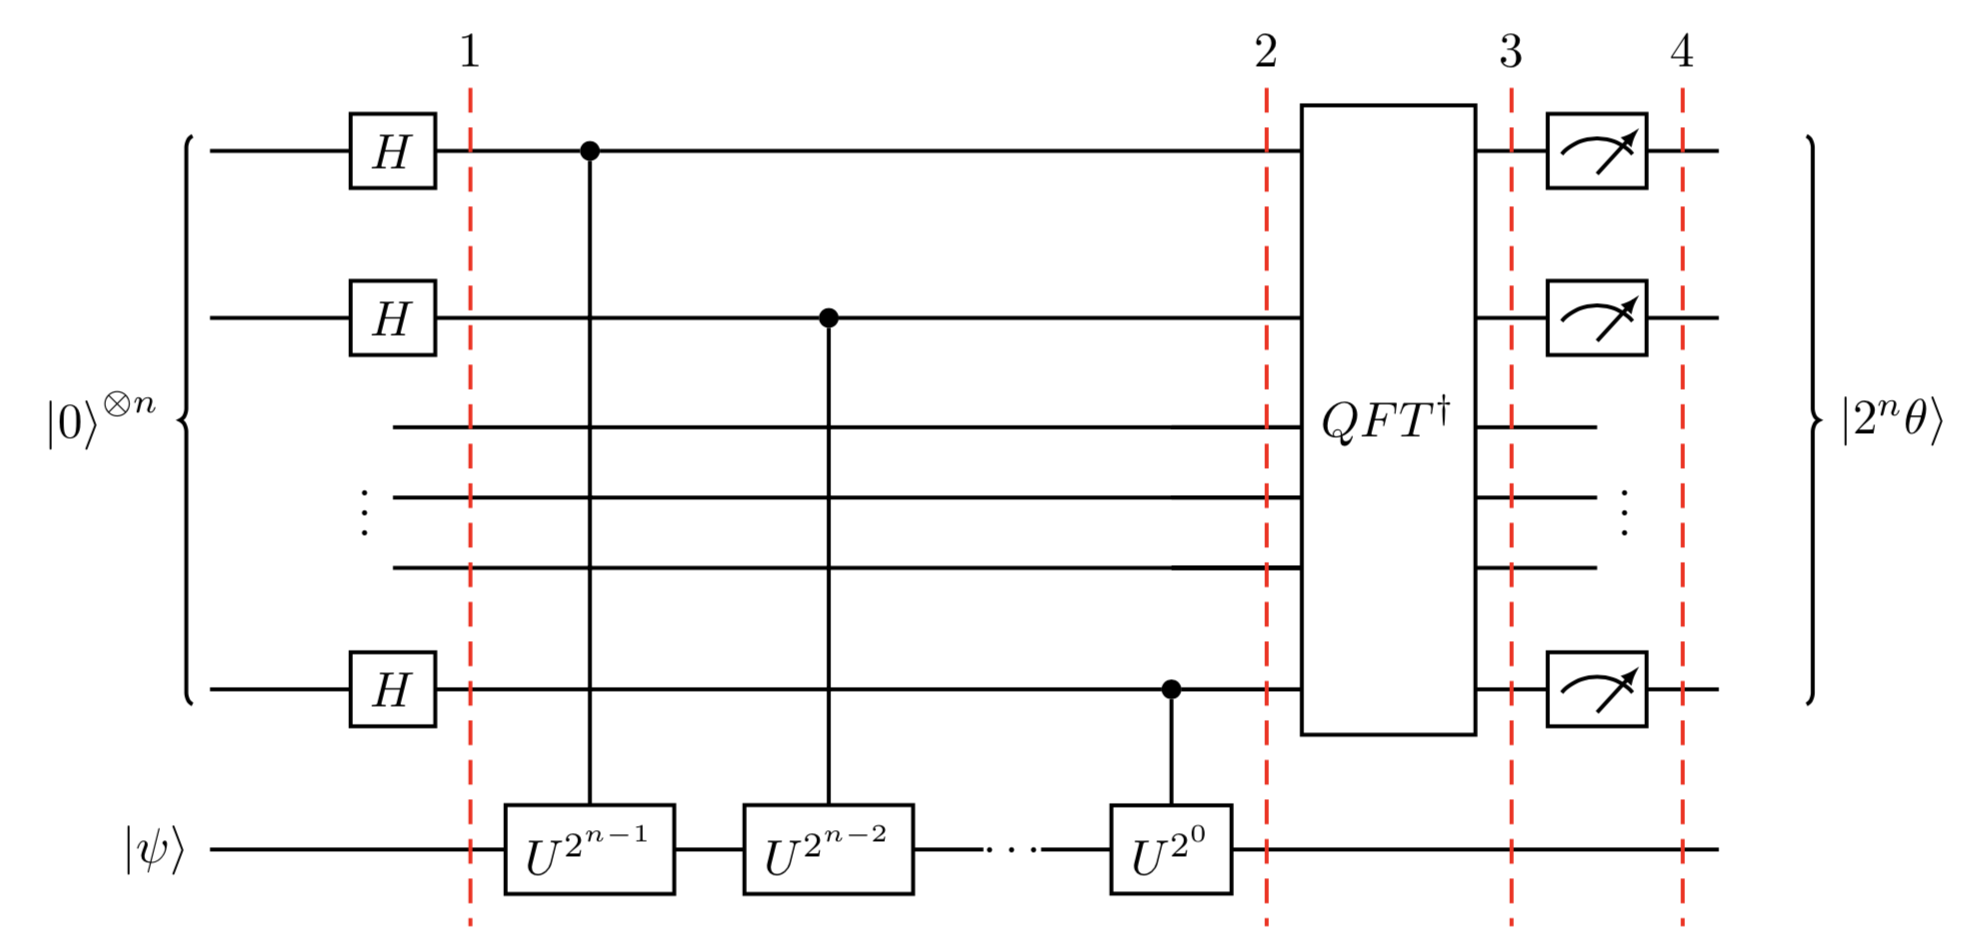

## Step 1: create all possible time samples

We begin with the state

$$|0\rangle^{\otimes m} \otimes |\psi\rangle$$

After the Hadamards, the counting register is

$$\frac{1}{\sqrt{2^m}}\sum_{x=0}^{2^m-1}|x\rangle.$$

So the full state is

$$\frac{1}{\sqrt{2^m}}\sum_{x=0}^{2^m-1}|x\rangle|\psi\rangle.$$

This is the quantum parallelism part. Every value of $x$ is present in the counting register.

## Step 2: Controlled Phasing

The key eigenvalue equation is

$$U|\psi\rangle=e^{2\pi i\theta}|\psi\rangle.$$

Apply $U$ twice:

$$U^2|\psi\rangle=U(e^{2\pi i\theta}|\psi\rangle)=e^{2\pi i\theta}U|\psi\rangle=e^{2\pi i(2\theta)}|\psi\rangle.$$

In general,

$$U^x|\psi\rangle=e^{2\pi i x\theta}|\psi\rangle.$$

A controlled-$U^x$ applies this phase only on the branch where the counting register contains $x$.

Controlled powers of $U$ produce

$$\frac{1}{\sqrt{2^m}}\sum_{x=0}^{2^m-1}|x\rangle|\psi\rangle \longrightarrow \frac{1}{\sqrt{2^m}}\sum_{x=0}^{2^m-1}e^{2\pi i x\theta}|x\rangle|\psi\rangle.$$

The counting register now contains a Fourier-like phase pattern:

$$|x\rangle\text{ has phase }e^{2\pi i x\theta}.$$

**QPE has converted the unknown eigenvalue phase into a phase wave across the counting basis states!**

## Step 3: Inverse QFT reads the phase

The QFT maps a computational basis label $y$ to a phase wave:

$$|y\rangle \mapsto \frac{1}{\sqrt{2^m}}\sum_{x=0}^{2^m-1}e^{2\pi i xy/2^m}|x\rangle.$$

After controlled-phasing, the counting register is

$$\frac{1}{\sqrt{2^m}}\sum_{x=0}^{2^m-1}e^{2\pi i x\theta}|x\rangle.$$

If $\theta$ has an exact $m$-bit binary expansion,

$$\theta=\frac{y}{2^m},$$

then this is exactly the QFT of $|y\rangle$.

Therefore $\text{QFT}^{-1} = \text{QFT}^\dagger$ returns

$$|y\rangle.$$

## Step 4: Measuring and Reading $\theta$

After the inverse QFT, the ideal exact state is

$$|y\rangle|\psi\rangle.$$

If $\theta$ has an exact $m$-bit binary expansion, then

$$y=2^m\theta,$$

so

$$|y\rangle|\psi\rangle=|2^m\theta\rangle|\psi\rangle.$$

When we measure the counting register, we get an integer bit string $y$.

To turn that bit string into a phase estimate, divide by $2^m$:

$$\widehat{\theta}=\frac{y}{2^m}.$$

Example with $m=3$:

$$y=101_2=5 \quad\Longrightarrow\quad \widehat{\theta}=\frac{5}{8}=0.625.$$

If $\theta$ is not exactly representable with $m$ bits, the most probable measurements are the integers nearest to $2^m\theta$. More counting qubits means a finer grid of possible estimates.

## Example

Suppose we have access to the following one-qubit unitary matrix.

$$U=\begin{bmatrix}1&0\\0&e^{2\pi i\theta}\end{bmatrix}.$$

Suppose we are also told that the state $|1\rangle$ is an eigenstate with

$$U|1\rangle=e^{2\pi i\theta}|1\rangle.$$

The following slide shows the QPE circuit with a choice of three counting qubits.

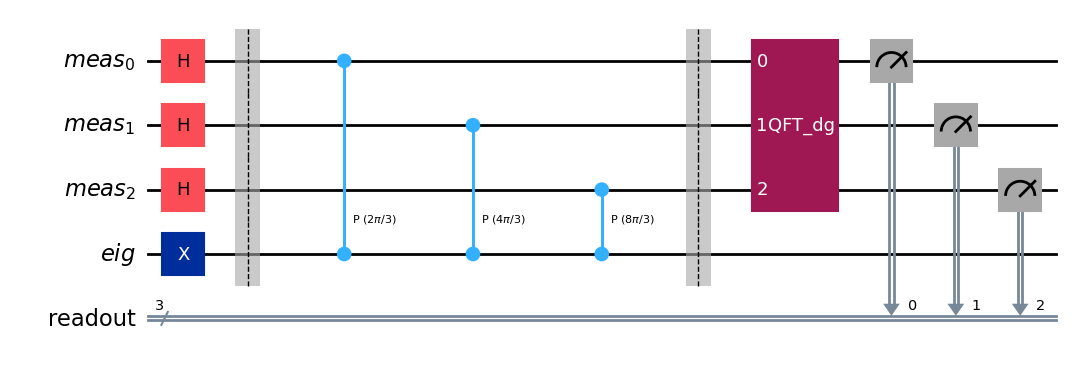

In [8]:
from qiskit import QuantumRegister, ClassicalRegister


def qpe_circuit(theta, n_counting, measure=True):
    # Build QPE for U = diag(1, exp(2*pi*i*theta)) and eigenstate |1>.
    measurement = QuantumRegister(n_counting, name='meas')
    eigenstate = QuantumRegister(1, name='eig')

    if measure:
        readout = ClassicalRegister(n_counting, name='readout')
        qc = QuantumCircuit(measurement, eigenstate, readout)
    else:
        qc = QuantumCircuit(measurement, eigenstate)

    # Step 1: counting register in a uniform superposition.
    for q in measurement:
        qc.h(q)

    # Prepare the eigenstate |psi> = |1> of U.
    qc.x(eigenstate[0])
    qc.barrier()

    # Step 2: controlled powers U^(2^q).
    # For this U, controlled-U^(2^q) is a controlled phase by 2*pi*theta*2^q.
    for q_index, q in enumerate(measurement):
        power = 2 ** q_index
        qc.cp(2*np.pi*theta*power, q, eigenstate[0])
    qc.barrier()

    # Step 3: inverse QFT on the counting register.
    qc.append(qft_circuit(n_counting).inverse(), measurement)

    # Step 4: measure only the counting register.
    if measure:
        qc.measure(measurement, readout)
    return qc

# This displayed circuit corresponds to the example unitary above with theta = 1/3.
qpe_demo = qpe_circuit(theta=1/3, n_counting=3, measure=True)
qpe_demo.draw(output='mpl')

## Exact Case Example

Suppose we choose $m=3$ counting qubits. And also suppose that

$$\theta=\frac{5}{8}=0.101_2.$$

Then

$$y=2^m\theta=8\cdot \frac58=5.$$

In binary,

$$5=101_2.$$

So ideal QPE should measure

$$101.$$

theta = 0.625
expected bits = 101
probabilities = {'101': 0.9999999999999991}


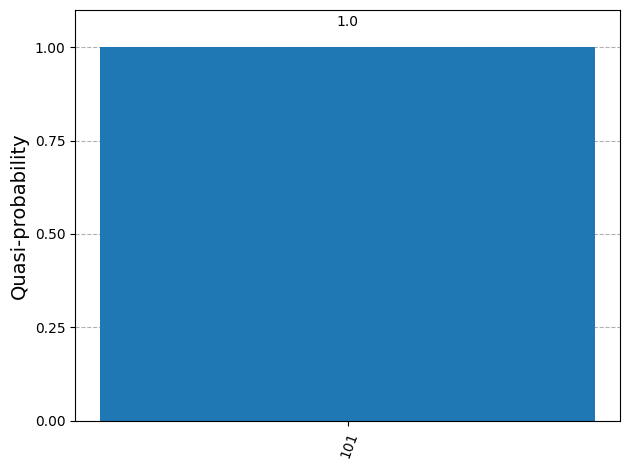

In [9]:
theta = 5/8
n_counting = 3
qpe_no_measure = qpe_circuit(theta, n_counting, measure=False)

state = Statevector.from_instruction(qpe_no_measure)
phase_probabilities = {
    str(bitstring): float(prob)
    for bitstring, prob in state.probabilities_dict(qargs=range(n_counting)).items()
    if prob > 1e-12
}

print('theta =', theta)
print('expected bits =', bits(int(theta * 2**n_counting), n_counting))
print('probabilities =', phase_probabilities)
plot_histogram(phase_probabilities)

## Non-Exact Case: QPE gives the Nearest Frequencies

If $\theta$ is not exactly representable with $m$ bits, then

$$2^m\theta$$

is not an integer.

The inverse QFT can no longer put all probability on one basis state.

Instead, the measurement is concentrated near integers $y$ satisfying

$$\frac{y}{2^m}\approx \theta.$$

So QPE still returns useful information: more counting qubits means a more precise estimate.

theta = 0.3333333333333333
3 counting qubits: most likely bits = 011, y = 3, theta estimate = 3/2^3 = 0.375
5 counting qubits: most likely bits = 01011, y = 11, theta estimate = 11/2^5 = 0.34375


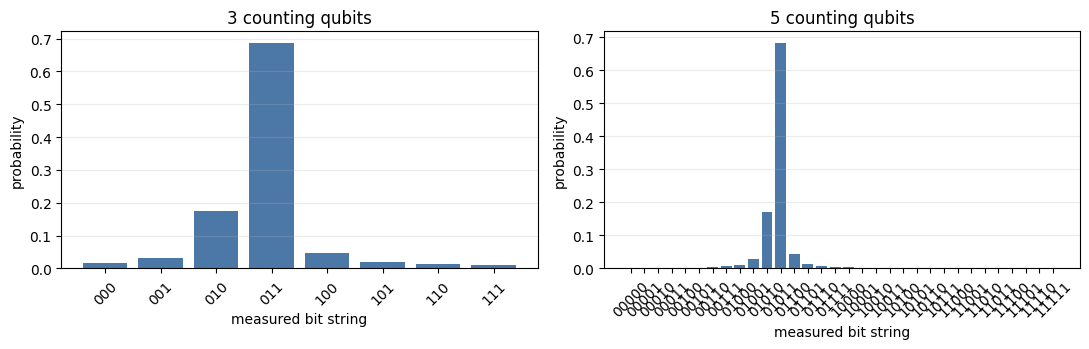

In [10]:
theta = 1/3

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
summary = []

for ax, n_counting in zip(axes, [3, 5]):
    qpe_no_measure = qpe_circuit(theta, n_counting, measure=False)
    state = Statevector.from_instruction(qpe_no_measure)
    probabilities = {
        str(bitstring): float(prob)
        for bitstring, prob in state.probabilities_dict(qargs=range(n_counting)).items()
        if prob > 1e-4
    }

    best_bits = max(probabilities, key=probabilities.get)
    best_y = int(best_bits, 2)
    best_estimate = best_y / 2**n_counting
    summary.append((n_counting, best_bits, best_y, best_estimate))

    ordered = sorted(probabilities.items(), key=lambda item: int(item[0], 2))
    labels = [bits for bits, _ in ordered]
    values = [prob for _, prob in ordered]
    ax.bar(labels, values, color='#4c78a8')
    ax.set_title(f'{n_counting} counting qubits')
    ax.set_xlabel('measured bit string')
    ax.set_ylabel('probability')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.25)

print('theta =', theta)
for n_counting, best_bits, best_y, best_estimate in summary:
    print(f'{n_counting} counting qubits: most likely bits = {best_bits}, y = {best_y}, theta estimate = {best_y}/2^{n_counting} = {best_estimate}')

plt.tight_layout()

## QPE Summary

Quantum phase estimation does this:

$$U|\psi\rangle=e^{2\pi i\theta}|\psi\rangle
\quad\Longrightarrow\quad
\text{estimate }\theta.$$

The QFT is the heart of the algorithm:

1. controlled powers of $U$ create the phase $e^{2\pi i x\theta}$,
2. the inverse QFT turns that phase into a computational-basis bit string,
3. measuring gives an approximation to $\theta$.

This same pattern appears inside many larger quantum algorithms, like Shor's factoring algorithm!